# **Applied Data Science in Medicine & Psychology - Assignment 10**
## Machine Learning
---
**Deadline: 21.07.2023, 23:59**
### **General setup and submission**
1. Save an editable copy of this notebook to your Google Drive ``File`` $\rightarrow$ ``Save a copy in Drive`` and remove the automatically appended "Copy of" text. **Do not change the file name**.
2. Work on the assignment in the *copied* version of the notebook. Make sure that you **replace** all parts of the tasks indicated with *YOUR CODE HERE* and **raise NotImplementedError()** (otherwise this causes an error in your implementation) or *YOUR ANSWER HERE* with your solution.
3. If you do a break during the implementation, you can save the current status of your work in your repository following the submission instructions below. When you continue working on the assignment, do this in the version of the notebook that you saved in your Google Drive (access from your Google Colab account) or your repository.
4. After finishing the assignment submit your assignment as follows:
    * Check that everything runs as expected. To do that select in the menubar ``Runtime`` $\rightarrow$ ``Restart and run all``. This will clear all your local variables and runs your notebook from the beginning
    * Save your notebook, click ``File`` $\rightarrow$ ``Save``
    * Click ``File`` $\rightarrow$ ``Save a copy in GitHub``
    * Select ``digikolleg-data-science-psychology/10_machine_learning-<username>`` from the Repository drop-down menu 
    * Type ``10_machine_learning.ipynb`` into the File path text box
    * Optionally, you may enter a description into the "Commit message" text box (like: "solved task 1" or "ready for grading")
    * Make sure that the "Include a link to Colaboratory" box is checked
    * Press "Ok"
    * A new tab or window should open up, displaying your submitted notebook within your GitHub repository

Before the assignment deadline, you can re-submit your assignment as often as you would like. This will update the copy of your assignment file in your assignment's repository.

### **Assignment Description**
***General description... TODO***

#### **Assignment goals**
You are going to learn the following things in this assignment:
1. ***TODO***
2. ***TODO***

#### **Assignment point value**
This assignment is worth a total (up to) ***X TODO*** point***(s) TODO***. If your code passes all of the manual and automatic tests you will receive full credit.

### **Tasks** (14 points)
Make sure that you now work on your *copied* version of this assignment's notebook.

#### 0. Imports and Setup
Please **run** the cell below to import the libraries needed for this assignment.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install biopsykit
import biopsykit as bp
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score#, plot_confusion_matrix
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_validate
from sklearn.svm import SVC


[notice] A new release of pip is available: 23.0 -> 23.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### 1. Data Loading and Dataframe Preparation
Create a ``pandas.DataFrame`` called ``df_cancer`` that contains all features and labels of the ``sklearn`` *Breast Cancer Wisconsin dataset*
* Load the dataset using ``load_breast_cancer()``. Have a look at the structure of the dataset. What is the dataset about? How many observations and features are included? How many observations are within every class?
* Create the dataframe ``df_cancer`` with features as columns and observations as rows. Set the feature names as column names.
* Add a column called ``label`` to ``df_cancer`` that indicates whether each breast cancer observation turned out to be malignant or benign. Use the actual words malignant and benign as class descriptors.

In [2]:
### BEGIN SOLUTION
data_cancer = load_breast_cancer()
df_cancer = pd.DataFrame(data_cancer["data"], columns=data_cancer["feature_names"])
df_cancer["label"] = data_cancer["target"] # 0: malignant, 1: benign
df_cancer.loc[df_cancer["label"] == 0, ["label"]] = "malignant"
df_cancer.loc[df_cancer["label"] == 1, ["label"]] = "benign"
df_cancer.head()
### END SOLUTION

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [3]:
# run cell to test your implementation
assert type(df_cancer) == pd.DataFrame, "df_cancer should be of type pandas.DataFrame"
assert df_cancer.shape == (569, 31), "Check if you included all features and the label vector in df_cancer"
assert df_cancer.columns[2] == "mean perimeter" and df_cancer.columns[-1] == "label", "Check if you set the column names correctly"
assert df_cancer["mean symmetry"].mean() > 0.18 and df_cancer["mean symmetry"].mean() < 0.182, "Check the data you set as feature data"
assert set(df_cancer["label"]) == {"benign", "malignant"}, "Check that you replace 0 and 1 with malignant and benign"
assert (df_cancer["label"] == "benign").sum() == 357, "Check the data you set as labels"

#### 2. Feature Visualization
* Visualize the features *mean radius*, *mean texture*, *mean smoothness*, *mean concavity*, and *mean symmetry* using a [seaborn.pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
* Set the parameters such that you can differentiate between the classes
* Have a look at the plot. Describe your thoughts about (in the cell below):
    * the distributions of the single features (diagonal). Why is it most of the time advantageous to include more than one feature in your analysis? 
    * the separability of classes
    * correlation between features

*YOUR ANSWER HERE*

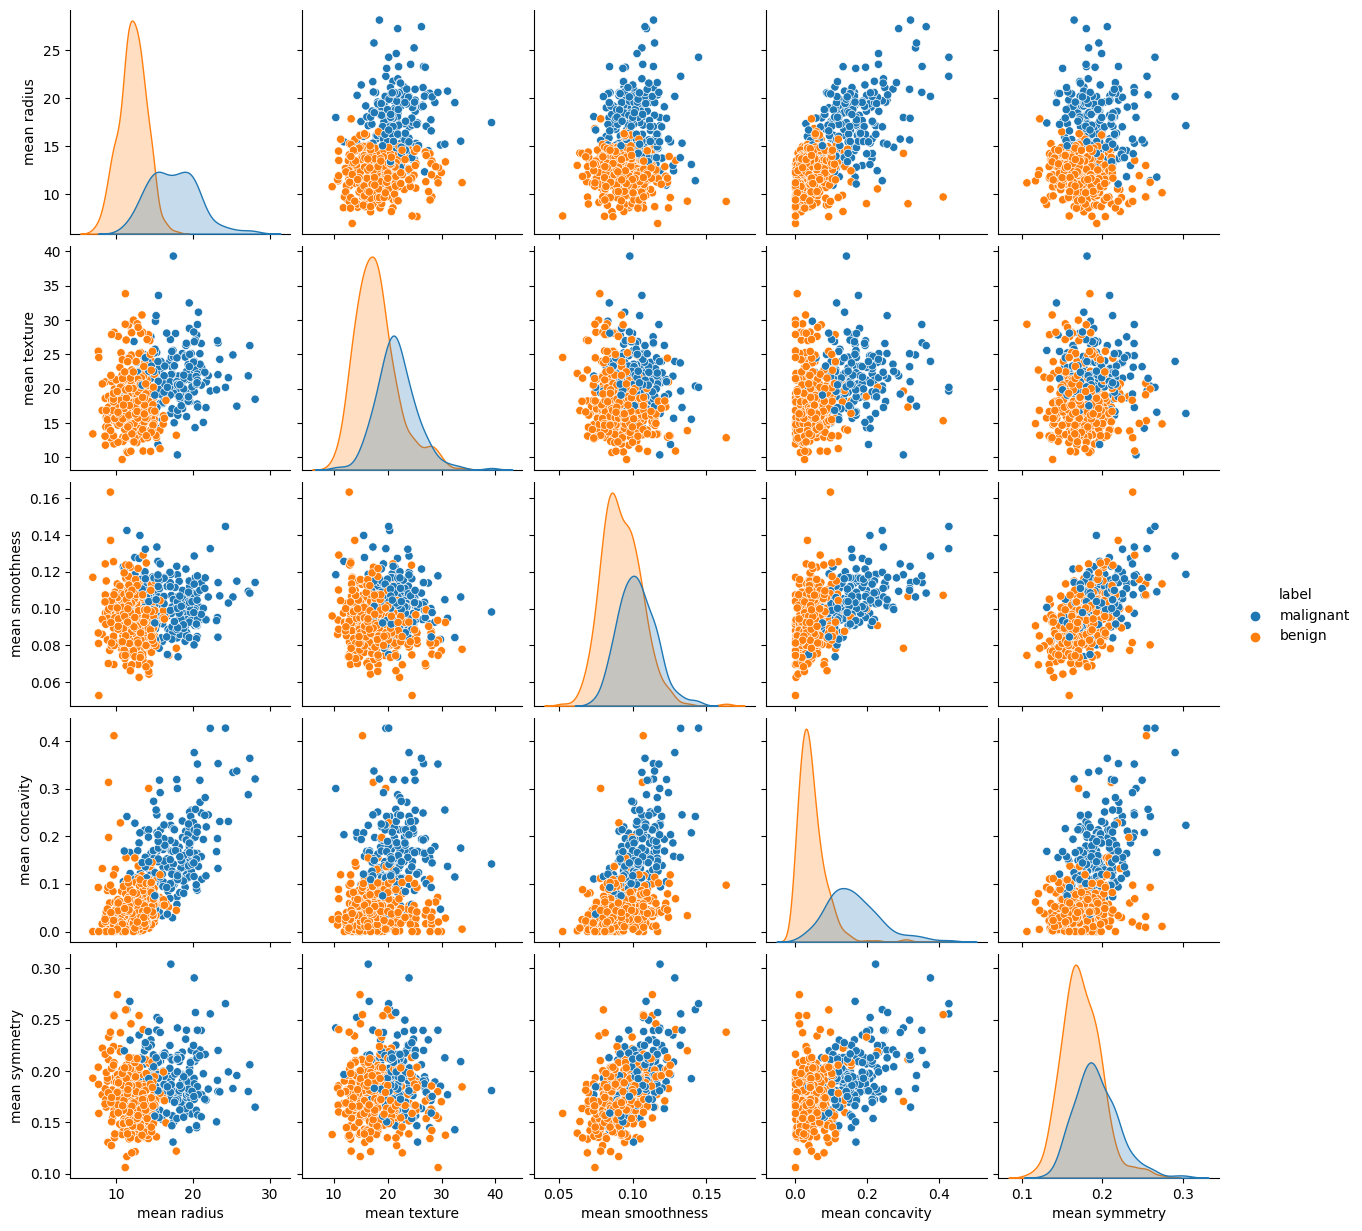

In [4]:
### BEGIN SOLUTION
data_plot = df_cancer.loc[:, ["mean radius", "mean texture", "mean smoothness", "mean concavity", "mean symmetry", "label"]]
pp = sns.pairplot(data=data_plot, hue="label")
### END SOLUTION

In [5]:
# run cell to test your implementation
assert type(pp) == sns.axisgrid.PairGrid, "Check that you create a pairplot using the seaborn library"
assert pp.x_vars == pp.y_vars and np.shape(pp.axes) == (5, 5), "Check that you create a pairplot"
assert set(pp.x_vars) == {"mean concavity", "mean radius", "mean smoothness", "mean symmetry", "mean texture"}, "Check the features in the pairplot"
assert pp.legend is not None, "Make sure that you can differentiate between the classes"

#### 3. Standardization
Create a function ``standardize_data`` with the parameter ``data`` that standardizes ``data`` by removing the mean and scaling it to unit variance:
* Create an instance of[sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
* Use its methods to fit the scaler to ``data`` and transform it such that every feature individually has zero mean and unit variance
* The function should return an array containing a standarized version of ``data``

In [6]:
### BEGIN SOLUTION
def standardize_data(data):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    return data_scaled
### END SOLUTION

In [7]:
# run cell to test your implementation
res_scaled = standardize_data(df_cancer.drop(columns="label"))
assert type(res_scaled) == np.ndarray, "Check that you return the standardized data as array"
assert np.shape(res_scaled) == (569, 30), "Check that you return value keeps the input dimensions"
assert np.sum(np.std(res_scaled, axis=0)) > 29.99, "Ensure that all features have unit variance after standardizing"
assert np.abs(np.sum(np.mean(res_scaled, axis=0))) < 1e-10, "Ensure that all features have zero mean after standardizing"

#### 4. Visualization Standardization
Create a figure with two subplots that visualizes 2 features the original and standardized dataset:
* Create a figure with two subplots using [matplotlib.pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) and save its return values in variables called ``fig`` and ``axs``
* Plot in the first subplot a scatter plot of *mean radius* and *mean texture* of the original dataset
* Plot in the second subplot a scatter plot of *mean radius* and *mean texture* of the standardized dataset
* Set x- and y-axis labels and the subplot titles according to the data
* Describe the effects that standardization has on the data in the cell below

**Hint**: You can also set the parameters ``sharex`` and ``sharey`` of [matplotlib.pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) to ``True`` to see some of the effects of standarization.

*YOUR ANSWER HERE*

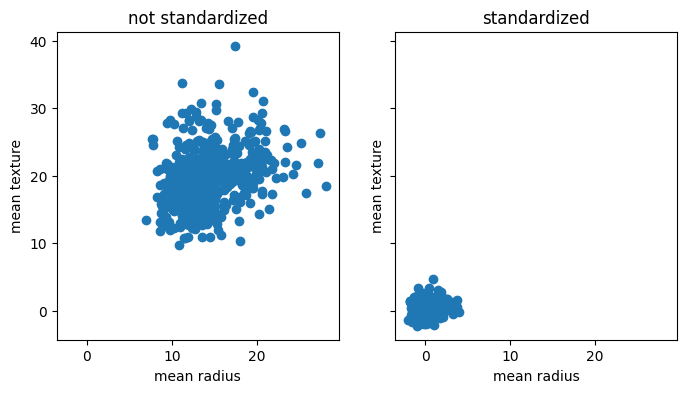

In [8]:
### BEGIN SOLUTION
res_scaled = standardize_data(df_cancer.drop(columns="label"))
fig, axs = plt.subplots(ncols=2, figsize=(8, 4), sharex=True, sharey=True)
axs[0].scatter(df_cancer["mean radius"], df_cancer["mean texture"])
axs[1].scatter(res_scaled[:, 0], res_scaled[:, 1])
for ax in axs: ax.set_xlabel("mean radius"); ax.set_ylabel("mean texture")
for ax, t in zip(axs, ["not standardized", "standardized"]): ax.set_title(t)
### END SOLUTION

In [9]:
# run cell to test your implementation
assert len(fig.axes) == 2, "Ensure that you create a figure with two subplots"
assert np.all(np.abs(fig.axes[1].xaxis.get_data_interval()) < 5) and np.all(np.abs(fig.axes[1].yaxis.get_data_interval()) < 5), "Ensure that you visualize the standardized versions of mean radius and mean texture in the right subplot"
assert len(fig.axes[0].get_xlabel()) != 0 and len(fig.axes[0].get_ylabel()) != 0, "Check the first subplot's x and y labels"
assert len(fig.axes[0].title.get_text()), "Check the first subplot's title"
assert len(fig.axes[1].get_xlabel()) != 0 and len(fig.axes[1].get_ylabel()) != 0, "Check the second subplot's x and y labels"
assert len(fig.axes[1].title.get_text()), "Check the second subplot's title"

#### 5. Feature Visualization
* Visualize the features *mean radius*, *mean perimeter*, *mean area*, *worst radius*, and *worst perimeter* using a [seaborn.pairplot](https://seaborn.pydata.org/generated/seaborn.pairplot.html)
* Set the parameters such that you can differentiate between the classes
* Have a look at the plot. Describe your thoughts about the correlation between features:

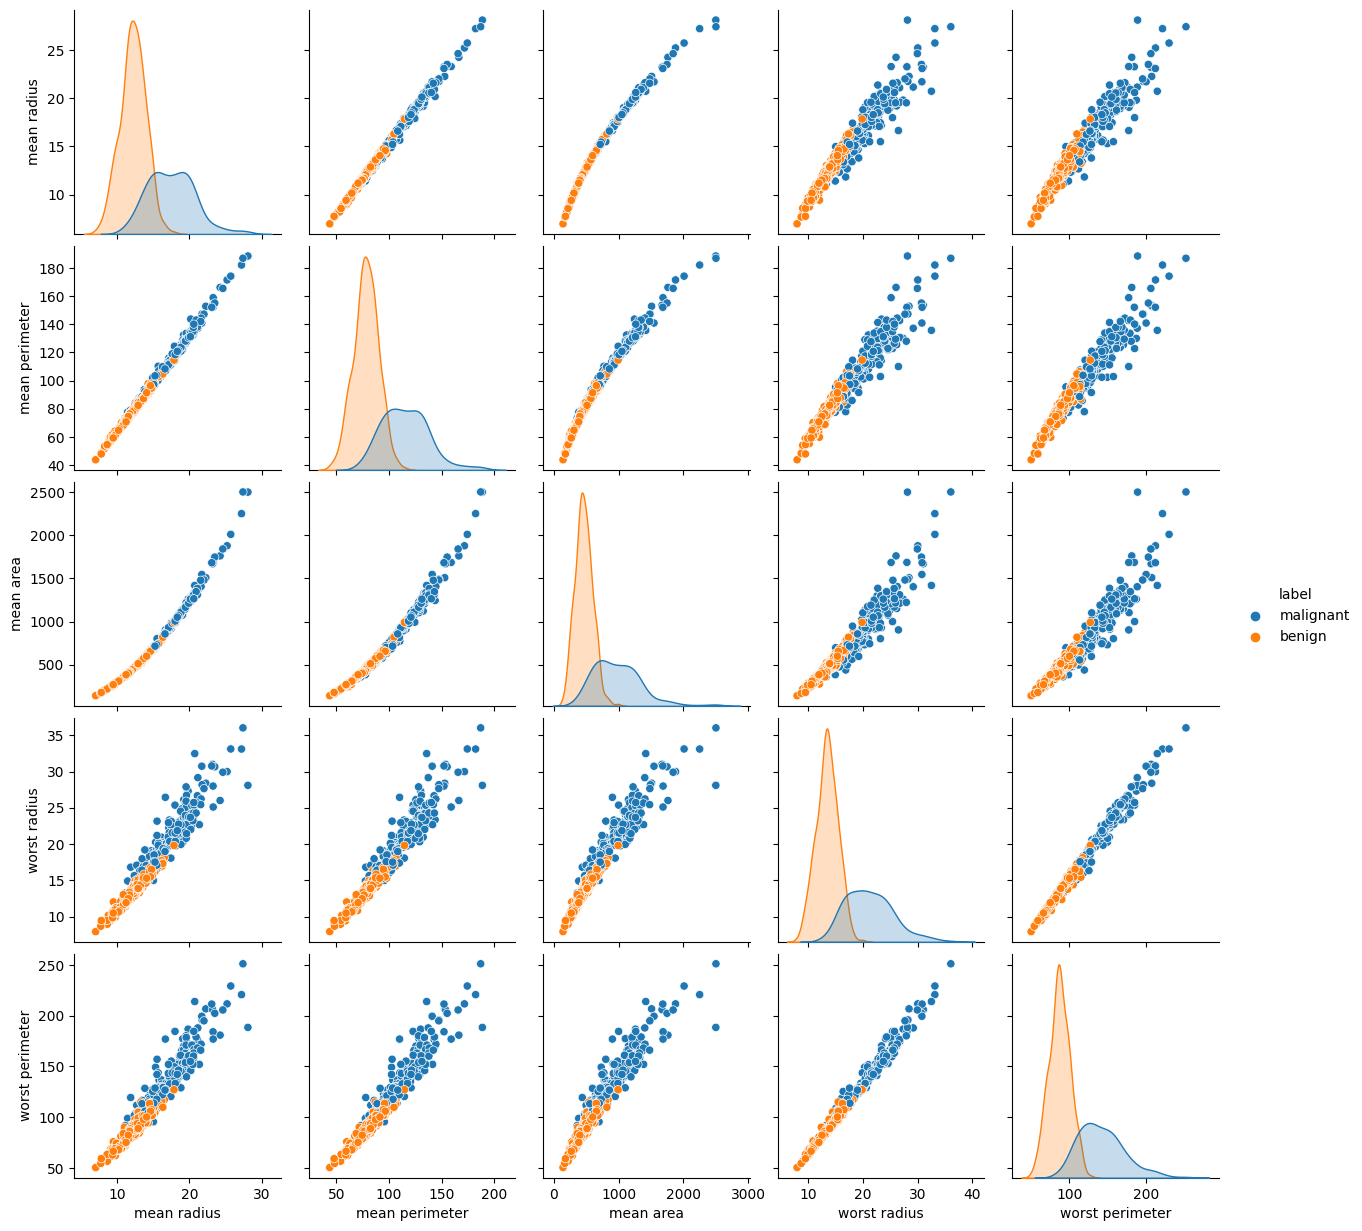

In [35]:
### BEGIN SOLUTION
data_plot = df_cancer.loc[:, ["mean radius", "mean perimeter", "mean area", "worst radius", "worst perimeter", "label"]]
pp = sns.pairplot(data_plot, hue="label")
### END SOLUTION

*YOUR ANSWER HERE*

In [36]:
# run cell to test your implementation
assert type(pp) == sns.axisgrid.PairGrid, "Check that you create a pairplot using the seaborn library"
assert pp.x_vars == pp.y_vars and np.shape(pp.axes) == (5, 5), "Check that you create a pairplot"
assert set(pp.x_vars) == {"mean area", "mean perimeter", "mean radius", "worst perimeter", "worst radius"}, "Check the features in the pairplot"
assert pp.legend is not None, "Make sure that you can differentiate between the classes"

#### 6. Dimensionality Reduction
Create a function ``reduce_dims`` with the parameters ``data`` and ``n_components`` that applies *Principal Component Analysis* (PCA) to ``data``:
* ``data``: ``numpy.ndarray`` containing the data (rows: observations, columns: features)
* ``n_components``: number of PCA components to be kept
* Create an instance of [sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). Set the parameters: *n_components*: ``n_components``, *svd_solver*: "full". Have a look at the *n_components* parameter, which options to you have to specify the parameter? 
* Use its methods to fit the PCA to ``data`` and transform ``data`` accordingly
* The function should return an array containing only the specified number of PCA components

In [12]:
### BEGIN SOLUTION
def reduce_dims(data, n_components):
    pca = PCA(n_components=n_components, svd_solver="full")
    data_pca = pca.fit_transform(data)
    return data_pca
### END SOLUTION

In [40]:
# run cell to test your implementation
data_pca = reduce_dims(df_cancer.drop(columns="label"), 2)
assert np.shape(data_pca) == (569, 2), "Check that you return the transformed data"
assert np.all(np.abs(np.mean(data_pca, axis=0)) < 1e-8), "Check that you return the transformed data"
assert np.all(np.mean(data_pca, axis=0) != df_cancer.drop(columns="label").mean(axis=0)[0:2].to_numpy()), "Check that you return the transformed data"
data_pca = reduce_dims(df_cancer.drop(columns="label"), 0.8)
assert np.shape(data_pca) == (569, 1), "Check that you accept also a value for explained variance as n_components"

#### X TODO

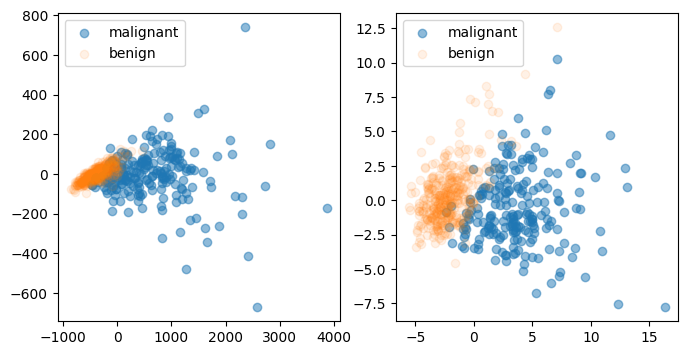

In [37]:
### BEGIN SOLUTION
fig, ax = plt.subplots(ncols=2, figsize=(8,4))

data_pca_1 = reduce_dims(df_cancer.drop(columns="label"), 2)

ax[0].scatter(data_pca_1[df_cancer["label"]=="malignant", 0], data_pca_1[df_cancer["label"]=="malignant", 1], alpha=0.5, label="malignant")
ax[0].scatter(data_pca_1[df_cancer["label"]=="benign", 0], data_pca_1[df_cancer["label"]=="benign", 1], alpha=0.1, label="benign")
ax[0].legend()

data_scaled = standardize_data(df_cancer.drop(columns="label"))
data_pca_2 = reduce_dims(data_scaled, 2)

ax[1].scatter(data_pca_2[df_cancer["label"]=="malignant", 0], data_pca_2[df_cancer["label"]=="malignant", 1], alpha=0.5, label="malignant")
ax[1].scatter(data_pca_2[df_cancer["label"]=="benign", 0], data_pca_2[df_cancer["label"]=="benign", 1], alpha=0.1, label="benign")
ax[1].legend()
### END SOLUTION

In [15]:
# run cell to test your implementation
assert len(fig.axes) == 2, "Check that you created a figure with two subplots"
assert fig.axes[0].xaxis.get_data_interval()[0] < -860 and fig.axes[0].xaxis.get_data_interval()[1] > 3860, "Check that you plot in the first subplot the results from the PCA on unscaled data"
assert fig.axes[1].xaxis.get_data_interval()[0] < -5 and fig.axes[0].xaxis.get_data_interval()[1] > 15, "Check that you plot in the second subplot the results from the PCA on scaled data"

#### X. Train Test Split
Create a function ``split_data`` that takes the parameters ``data``, ``labels``, ``test_size``, and ``stratify`` and 

In [16]:
### BEGIN SOLUTION
def split_data(data, labels, test_size, stratify=None):
    X_train, X_test, Y_train, Y_test = train_test_split(data, labels, test_size=test_size, stratify=labels, random_state=10)
    return X_train, X_test, Y_train, Y_test
### END SOLUTION

In [41]:
# run cell to test your implementation
data_test = np.array(range(50)).reshape(10, -1); label_test = np.zeros(10); label_test[5:] = 1
data_split = split_data(data_test, label_test, 0.3, label_test)
assert np.shape(data_split[0]) == (7, 5) and np.shape(data_split[1]) == (3, 5) and np.shape(data_split[2]) == (7,) and np.shape(data_split[3]) == (3,), "Check that your return values are in the right order"

#### X Classification
Problems due to imbalanced dataset

In [18]:
# TODO: re do nicer + evaluation + confusion matrix

### BEGIN SOLUTION
df_c = df_cancer.drop(columns="label")
labels = df_cancer["label"]
df_scaled = standardize_data(df_c)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(df_scaled)
X_train, X_test, Y_train, Y_test = split_data(data_pca, labels, 0.3, labels)
svc = SVC(kernel="rbf")
svc.fit(X_train, Y_train)
print("train:", svc.score(X_train, Y_train))
print("test:", svc.score(X_test, Y_test))
### END SOLUTION

train: 0.9447236180904522
test: 0.9415204678362573


In [19]:
X_train, X_test, Y_train, Y_test = split_data(df_c, labels, 0.3, labels)
svc = SVC(kernel="rbf")
svc.fit(X_train, Y_train)
print("train:", svc.score(X_train, Y_train))
print("test:", svc.score(X_test, Y_test))

train: 0.9095477386934674
test: 0.8947368421052632


In [20]:
# run cell to test your implementation

### **Bonus Tasks** (5 points)

#### 1. Regression

In [21]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
diabetes = load_diabetes()
data_diabetes = diabetes["data"]
diabetes_y = diabetes["target"]

Coefficients: 
 [938.23786125]
Mean squared error: 2548.07
Coefficient of determination: 0.47


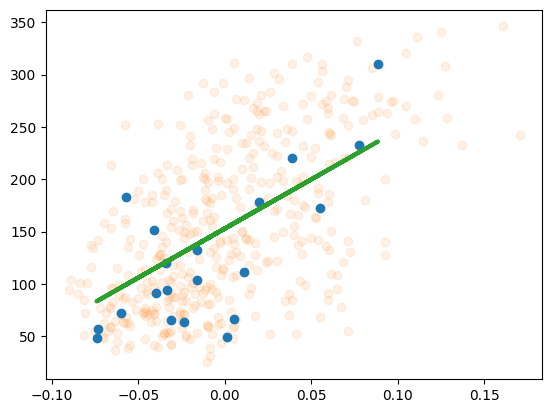

In [23]:
diabetes_X = data_diabetes[:, np.newaxis, 2]

# Split the data into training/testing sets
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]

# Split the targets into training/testing sets
diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]

# Create linear regression object
regr = LinearRegression()

# Train the model using the training sets
regr.fit(diabetes_X_train, diabetes_y_train)

# Make predictions using the testing set
diabetes_y_pred = regr.predict(diabetes_X_test)

# The coefficients
print("Coefficients: \n", regr.coef_)
# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(diabetes_y_test, diabetes_y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(diabetes_y_test, diabetes_y_pred))

# Plot outputs
plt.scatter(diabetes_X_train, diabetes_y_train, color="tab:orange", alpha=0.1)
plt.scatter(diabetes_X_test, diabetes_y_test, color="tab:blue")
plt.plot(diabetes_X_test, diabetes_y_pred, color="tab:green", linewidth=3)


#### 2. Clustering

In [24]:
np.random.seed(0)
gauss_1 = np.random.normal(loc=(10, 5), scale=(1, 3), size=(100, 2))
gauss_2 = np.random.normal(loc=(12, 12), scale=(2, 1), size=(100, 2))
gauss_3 = np.random.normal(loc=(16, 8), scale=1, size=(100, 2))

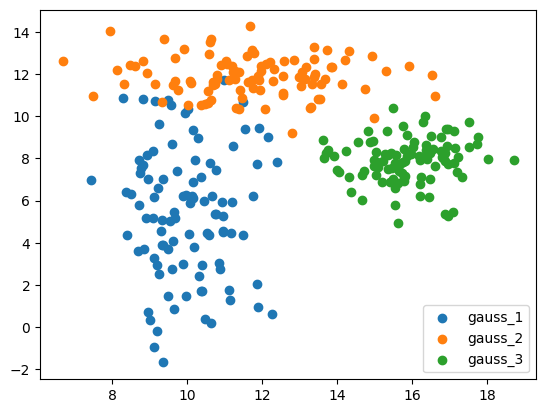

In [25]:
fig = plt.figure()
plt.scatter(gauss_1[:, 0], gauss_1[:, 1], label="gauss_1")
plt.scatter(gauss_2[:, 0], gauss_2[:, 1], label="gauss_2")
plt.scatter(gauss_3[:, 0], gauss_3[:, 1], label="gauss_3")
plt.legend()

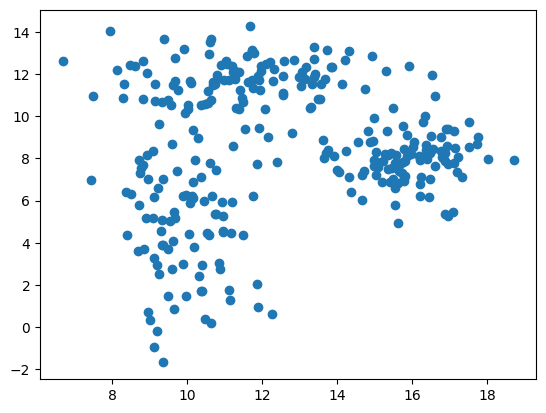

In [26]:
gauss = np.concatenate([gauss_1, gauss_2, gauss_3])
fig = plt.figure()
plt.scatter(gauss[:, 0], gauss[:, 1])

In [27]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto")
kmeans.fit(gauss)
labels_pred = kmeans.labels_

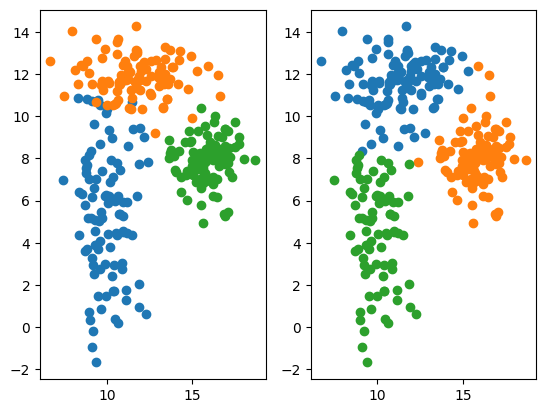

In [28]:
fig, axs = plt.subplots(ncols=2)
axs[0].scatter(gauss_1[:, 0], gauss_1[:, 1], label="gauss_1")
axs[0].scatter(gauss_2[:, 0], gauss_2[:, 1], label="gauss_2")
axs[0].scatter(gauss_3[:, 0], gauss_3[:, 1], label="gauss_3")
axs[1].scatter(gauss[labels_pred==0, 0], gauss[labels_pred==0, 1], label="cluster_1")
axs[1].scatter(gauss[labels_pred==1, 0], gauss[labels_pred==1, 1], label="cluster_2")
axs[1].scatter(gauss[labels_pred==2, 0], gauss[labels_pred==2, 1], label="cluster_3")

#### 3. Classification

In [29]:
data_cortisol = bp.example_data.get_saliva_example()
sample_times = [-30, -1, 30, 40, 50, 60, 70]
# fig, ax = plt.subplots(figsize=(6, 3))
# bp.protocols.plotting.saliva_plot(
#     data=data_cortisol, saliva_type="cortisol", sample_times=sample_times, test_times=[0, 30], sample_times_absolute=True,
#     test_title="Study Phase", ax=ax,
# );

In [30]:
auc = bp.saliva.auc(
    data_cortisol, saliva_type="cortisol", sample_times=sample_times, compute_auc_post=True, remove_s0=True
)
max_inc = bp.saliva.max_increase(data_cortisol, saliva_type="cortisol", remove_s0=True)
slope = bp.saliva.slope(data_cortisol, sample_idx=[1, 4], sample_times=sample_times, saliva_type="cortisol")

cort_features = pd.concat([auc, max_inc, slope], axis=1)
labels = np.array(cort_features.index.get_level_values(0))
data_analysis = cort_features.droplevel(0, axis=0)
# data_analysis.head()

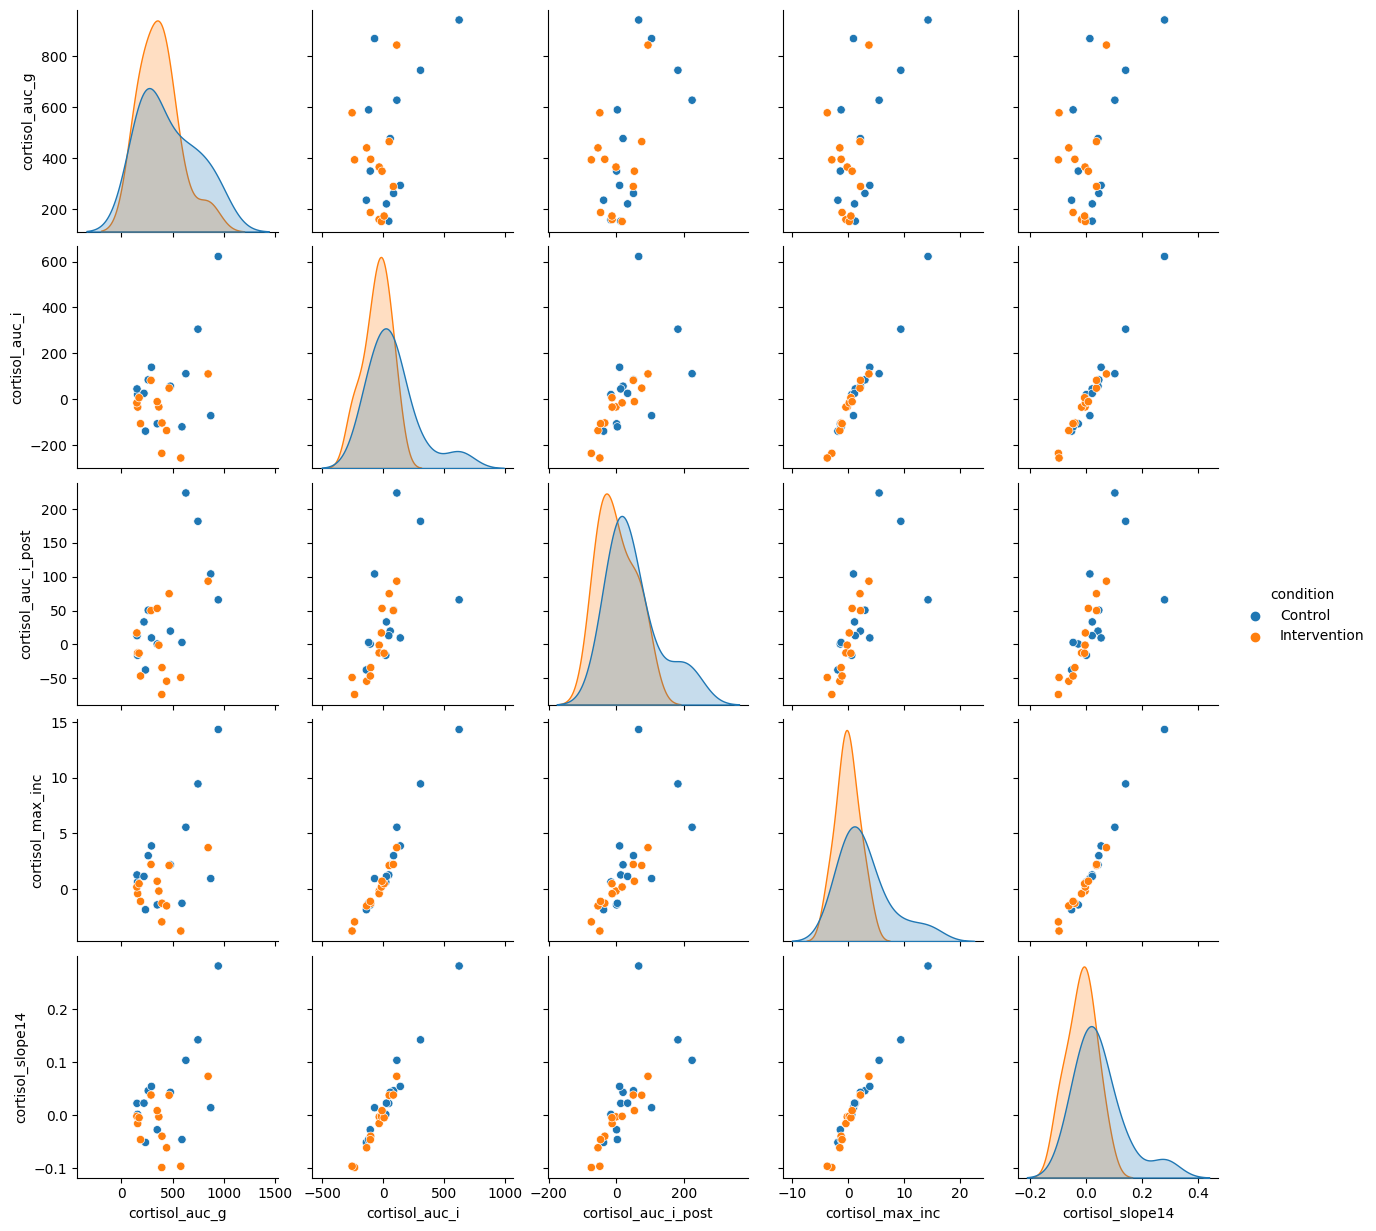

In [31]:
# run cell to visualize features
data_plot = cort_features.reset_index()
sns.pairplot(data=data_plot, hue="condition")

In [32]:
n_est = 100

##### X.X Train on complete dataset

##### X.X Train on train test split -> not the whole dataset used

In [33]:
clf = RandomForestClassifier(n_estimators=n_est)
clf.fit(X=X_train, y=Y_train)
print("train:", clf.score(X_train, Y_train))
print("test:", clf.score(X_test, Y_test))

train: 1.0
test: 0.9590643274853801


##### X.X Train with cross validation
- whole dataset used
- mean and std angeben model evaluation (robustness)

In [34]:
X_train, X_test, Y_train, Y_test = split_data(data_analysis, labels, 0.3, labels)
clf = RandomForestClassifier(n_estimators=n_est)
scores = cross_validate(clf, X_train, Y_train, cv=5, return_train_score=True, return_estimator=True)
scores

{'fit_time': array([0.27699685, 0.15200186, 0.15699649, 0.15300155, 0.15594792]),
 'score_time': array([0.01199746, 0.01099634, 0.01100683, 0.01196408, 0.01299858]),
 'estimator': [RandomForestClassifier(),
  RandomForestClassifier(),
  RandomForestClassifier(),
  RandomForestClassifier(),
  RandomForestClassifier()],
 'test_score': array([0.5       , 0.5       , 0.75      , 0.33333333, 0.33333333]),
 'train_score': array([1., 1., 1., 1., 1.])}